# Real-time Communication

In [1]:
import networkx as nx 
from dataXplorer import JupyterClient
from dataXplorer import AnalysisToolkit, SessionManager, TextureGenerator, ProjectFileManager, VisualizerSyncer

### 01 : Clients enter Space 

In [5]:
# run backend (server) using buildandrun powershell script
client = JupyterClient()

✅ Connected to /main


In [4]:
#client.disconnect()

### 02 : Code Client: Create new Project 

In [4]:
G = nx.barabasi_albert_graph(200, 3)
#G = nx.circular_ladder_graph(200)
print("Number of nodes: ", len(G.nodes()))
print("Number of Links: ", len(G.edges()))

G.graph['projectname'] = "Realtime-project"
G.graph['info'] = "A toy graph for testing purposes. Number of nodes: "+str(len(G.nodes()))+", Links: "+ str(len(G.edges()))+"."

posG = nx.spring_layout(G, dim=3)
posG_3D = dict(zip(G.nodes(),[i.tolist() for i in posG.values()])) # 3D positions
nx.set_node_attributes(G, posG_3D, 'pos')

blueblue = '#153fe7'
d_nodecolors_hex = dict(zip(G.nodes(),[blueblue]*len(G.nodes()))) 
nx.set_node_attributes(G, d_nodecolors_hex, 'nodecolor')

lightblue = '#5c7bf5'
l_linkcolors_hex = lightblue
nx.set_edge_attributes(G, l_linkcolors_hex, 'linkcolor')


import nx2json as nx2j 
nx2j.create_project(G)

Number of nodes:  200
Number of Links:  591
Successfully created the directory static/projects/Realtime-project 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: made textures for linkcolors...
PROGRESS: writing json files for project and nodes...
Project created successfully.


In [5]:
# import networkx as nx 
# import pandas as pd

# # TEAPOT TEST PROJECT
# G = nx.read_edgelist("temp-files/teapot-raw/teapot40_links.csv", delimiter=',', nodetype=int)
# print("Number of nodes: ", len(G.nodes()))
# print("Number of Links: ", len(G.edges()))

# G.graph['projectname'] = "TEAPOT-RealtimeTesting"
# G.graph['info'] = "A toy graph for testing purposes. Number of nodes: "+str(len(G.nodes()))+", Links: "+ str(len(G.edges()))+"."

# nodepos = pd.read_csv("temp-files/teapot-raw/teapot40_nodes.csv", delimiter=',',header =None)
# pos = dict(zip(G.nodes(), zip(nodepos[0], nodepos[1], nodepos[2])))
# nx.set_node_attributes(G, pos, 'pos')

# d_nodecolors_hex = dict(zip(G.nodes(),['#ff0000']*len(G.nodes())))
# nx.set_node_attributes(G, d_nodecolors_hex, 'nodecolor')

# l_linkcolors_hex = '#ff0000' # in rgba = (255,0,0,100)
# nx.set_edge_attributes(G, l_linkcolors_hex, 'linkcolor')

# import nx2json as nx2j 
# nx2j.create_project(G)

##### check project list of backend for newly created project and switch to it 

In [6]:
# see if new project is in projectlist
import GlobalData as GD

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, '00x-test-smallgraph'),
 (1, 'CDK5'),
 (2, 'CircLadderGraph-xsmall'),
 (3, 'CLGraph_TEST'),
 (4, 'diffusion'),
 (5, 'Exposurome'),
 (6, 'GenExpression_01'),
 (7, 'GenExpression_02'),
 (8, 'imunet_250130-X0-inter'),
 (9, 'imunet_250130-X1-inter'),
 (10, 'Interactive_Project_T01'),
 (11, 'JSON_autocore'),
 (12, 'JSON_barbellgraph'),
 (13, 'JSON_Zachary'),
 (14, 'Powergrid_Europe'),
 (15, 'Realtime-project'),
 (16, 'Sphere_Torus'),
 (17, 'Sphere_Torus_Morph'),
 (18, 'Teapot'),
 (19, 'TEAPOT-RealtimeTesting'),
 (20, 'TheMandelbulb_edges')]

In [9]:
# select a project to work with
sel_id = 0
sel_name = allprojects_updated[sel_id][1]

# load the project data
session = SessionManager(sel_id, sel_name, client)
session.load_graph_from_project()
session.reload_project()

# initialize 
file_mgr = ProjectFileManager(session)
tex_gen = TextureGenerator(session)
syncer = VisualizerSyncer(session)

Session Graph loaded from project folder. Data: Nodes: 3805 Links: 8253


✅ Connected to /main


In [11]:
G = session.load_graph_from_project()


Session Graph loaded from project folder. Data: Nodes: 3805 Links: 8253


#### check layout and colors selected 

In [9]:
latest_message = client.latest_data
session.get_active_layouts(latest_message)

Layout: layoutname_0 Selected index: 0


✅ Connected to /main


### 03 : VR-Client select node in 3D - Code-Client update texture

In [11]:
# select nodes - vis immediately triggered to show links + highlighted node

tools = AnalysisToolkit(session, tex_gen, syncer, file_mgr)

✅ Connected to /main


Found Links :  16
Subgraph:  None


(None, None)

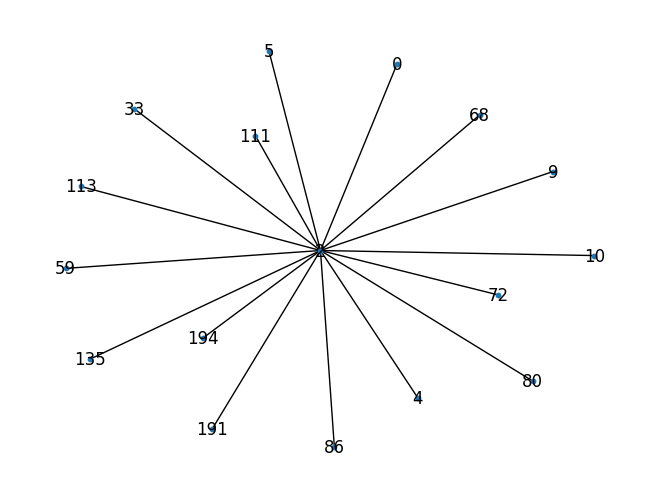

In [15]:
node_id = 2
tools.highlight_node_withlinks(node_id, temp_name="temp_node_highlight_geo")

None


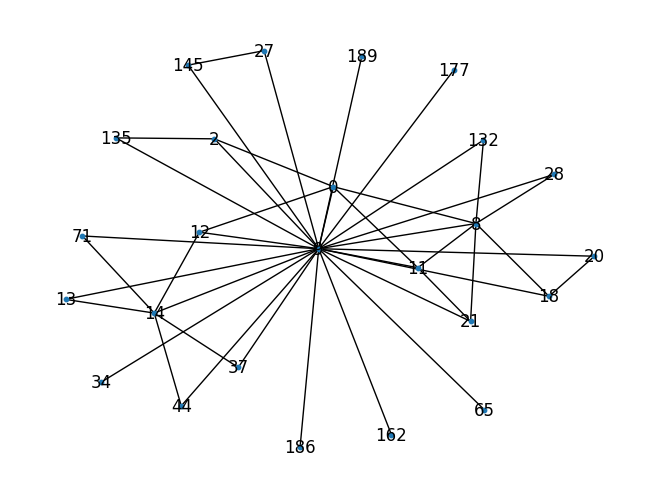

In [19]:
# extract subnetwork from selected node  

node_id = 9
tools.extract_and_highlight_subnetwork(node_id, relayout=False)


None


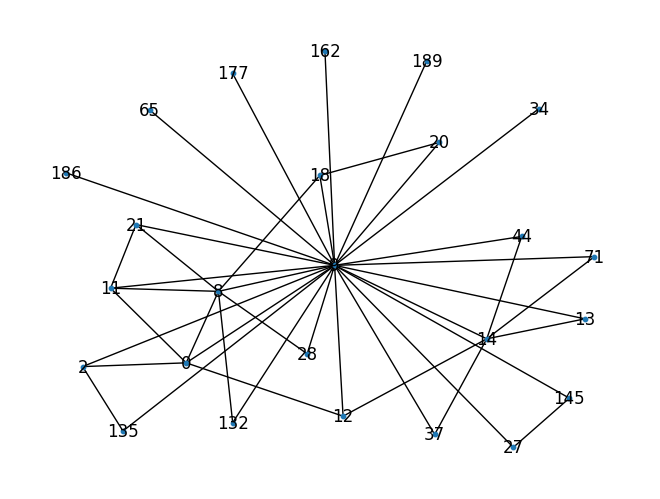

In [17]:
# extract subnetwork from selected node  

node_id = 9
tools.extract_and_highlight_subnetwork(node_id, relayout=True)


### 04 : Code Client - relayout subgraph (other nodes in periphery) for VR client 
+ subgraph in center (spring) - show nodes and links 
+ peripheral nodes in dark color and spherical surrounding

None


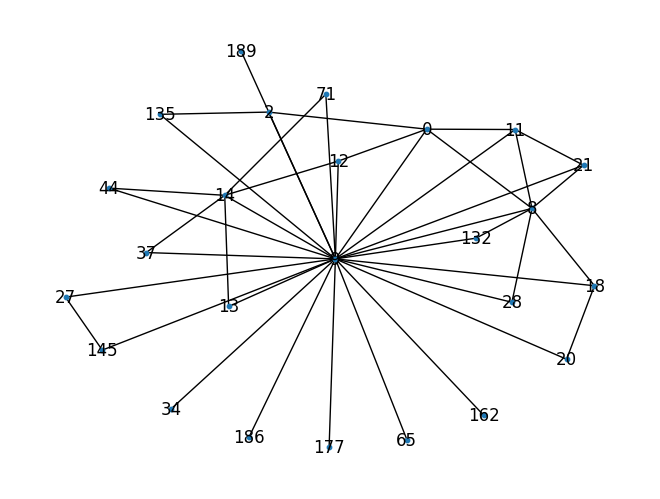

✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main
✅ Connected to /main


In [21]:
node_id = 9
tools.extract_and_highlight_subnetwork(node_id, relayout=True, color = (255,0,0,200))

In [ ]:
# TO DO / CONTINUE 

# temp vs permanent layout 
# - handling via flag in texture generating functions ?
# - needs filenames of new layout to pfile storing etc .. 

# morphing option instead of quick changes

# computational issue - how to handle for large graphs 

# access of existing functionality in analytics 

# clean up classes / reshuffle and refactor functions to "where they belong"

### 04 : relayout whole network  based on node annotations 

### 05 :  ADD SELECTIONS (realtime "landmarks") (VR-client)

In [ ]:
# SCENARIO 
# jupyter receive selected nodes from VR 
# 

# ---  SNIPPETS --- 

# OLD manual texture generation

### MODIFY PROJECT REAL TIME
- node colors 
- link colors
- node positions

In [ ]:
# change linkcolors 

visible_links = list(G.edges())#[::10]
print(len(visible_links))
print(visible_links[:10])

linkcolors = [(255,0,255,100)]

new_texture_name = 'teapot_showALLlinks'

In [ ]:
from PIL import Image

hight = 64 * (int((len(list(G.edges()))) / 32768) + 1)
path = 'static/projects/' + sel_name 
texc = [(0,0,0,10)] * 512 * hight  
new_imgc = Image.new('RGBA', (512, hight))

link_rgba = [(l,c) for l in visible_links for c in linkcolors]
    
edge_to_index = {tuple(edge): i for i, edge in enumerate(G.edges())}
for l, c in link_rgba:
    if tuple(l) in edge_to_index:
        i = edge_to_index[tuple(l)]
        texc[i]  = (int(c[0]),int(c[1]),int(c[2]),int(c[3]))

new_imgc.putdata(texc)
pathRGB = path + '/linksRGB/' + new_texture_name +'.png' 
new_imgc.save(pathRGB, "PNG")


In [ ]:
# SAVE TO PERMAMENT FILE STRUCTURE

# add to pfile channel 
import json
pfile = path + '/pfile.json'
with open(pfile) as f:
    data = json.load(f)

    # if not exists add
    if new_texture_name not in data['linksRGB']:
         data['linksRGB'].append(new_texture_name)
    
    # also add to other channels
    if new_texture_name not in data['layouts']:
        data['layouts'].append(new_texture_name)
    if new_texture_name not in data['layoutsRGB']:
        data['layoutsRGB'].append(new_texture_name)

with open(pfile, 'w') as f:
    json.dump(data, f, indent=4)


# add textures to other channels for file number consistency
import shutil
import os

# read all files in a folders
current_layouts = os.listdir(path + '/layouts')
current_layoutsrgb = os.listdir(path + '/layoutsRGB')
current_layoutsl = os.listdir(path + '/layoutsl')
print("Current layouts: ", current_layouts)

# copy one of the files via index and save as new name = same as texture generated 
shutil.copy(path + "/layouts/" + current_layouts[0], path + "/layouts/" + new_texture_name + ".bmp")
shutil.copy(path + "/layoutsRGB/" + current_layoutsrgb[0], path + "/layoutsRGB/" + new_texture_name + ".png")
shutil.copy(path + "/layoutsl/" + current_layoutsl[0], path + "/layoutsl/" + new_texture_name + "l.bmp")

In [ ]:
# UPDATE TEXTURE AND SEND TO FRONTEND 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': "updateTempTex",
    'id': 'linksRGBDD',
    'textures':[{"channel": "linkRGB", 
                  'path': "static/projects/"+ sel_name  + "/linksRGB/" + new_texture_name + ".png"}]
}, namespace='/main')

In [ ]:
# RELOAD CURRENT PROJECT 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')


### REAL-TIME LAYOUTS

In [ ]:
# MODIFY NODE POSITION 

new_layout_name = "C_temp"


# FUNCTION FOR NODE XYZ texture
hight = 128 * (int((len(G.nodes())) / 16384) + 1)
size = 128 * hight 
path = 'static/projects/' + sel_name 
    
texh = [(0,0,0)] * size
texl = [(0,0,0)] * size

# add layout here !!!!!!!!!
# the below part is dummy data for testing
nodes_pos = nx.get_node_attributes(G, 'pos') 
new_node_pos = {k: (v[0], v[2], v[1]) for k, v in nodes_pos.items()}

for i in range(len(new_node_pos)):

    x = int(float(new_node_pos[i][0])*65280)
    y = int(float(new_node_pos[i][1])*65280)
    z = int(float(new_node_pos[i][2])*65280)

    xh = int(x / 255)
    yh = int(y / 255)
    zh = int(z / 255)

    xl = x % 255
    yl = y % 255
    zl = z % 255

    pixelh = (xh,yh,zh)
    pixell = (xl,yl,zl)

    texh[i] = pixelh
    texl[i] = pixell

new_imgh = Image.new('RGB', (128, hight))
new_imgl = Image.new('RGB', (128, hight))
new_imgh.putdata(texh)
new_imgl.putdata(texl)

pathXYZ = path + '/layouts/' +  new_layout_name + '.bmp'
pathXYZl = path + '/layoutsl/' +  new_layout_name  + 'l.bmp' 
new_imgh.save(pathXYZ)
new_imgl.save(pathXYZl)


In [ ]:
# CHANGE NODE COLORS 

new_nodecolors = [[68,51,255,80]] * len(G.nodes())

# FUNCTION FOR NODE COLORS TEXTURE
hight = 128 * (int((len(G.nodes())) / 16384) + 1)
size = 128 * hight 
path = 'static/projects/' + sel_name
tex = [(0,0,0,10)] * size

for i in range(len(new_nodecolors)): 
    tex[i] = (int(new_nodecolors[i][0]), int(new_nodecolors[i][1]),int(new_nodecolors[i][2]),int(new_nodecolors[i][3]))

new_img = Image.new('RGBA', (128, hight))
new_img.putdata(tex)
pathRGB = path + '/layoutsRGB/' +  new_layout_name + '.png'
new_img.save(pathRGB , "PNG")


In [ ]:
# ADD ANOTHER LINKLIST TEXTURE 

visible_links = list(G.edges())[::50]

hight = 64 * (int((len(list(G.edges()))) / 32768) + 1)
path = 'static/projects/' + sel_name 
texc = [(0,0,0,10)] * 512 * hight  
new_imgc = Image.new('RGBA', (512, hight))

link_rgba = [(l,c) for l in visible_links for c in linkcolors]
    
edge_to_index = {tuple(edge): i for i, edge in enumerate(G.edges())}
for l, c in link_rgba:
    if tuple(l) in edge_to_index:
        i = edge_to_index[tuple(l)]
        texc[i]  = (int(c[0]),int(c[1]),int(c[2]),int(c[3]))

new_imgc.putdata(texc)
pathRGB = path + '/linksRGB/' + new_layout_name +'.png' 
new_imgc.save(pathRGB, "PNG")

In [ ]:
# SAVE TO PERMAMENT FILE STRUCTURE

# add to pfile channel 
import json
pfile = path + '/pfile.json'
with open(pfile) as f:
    data = json.load(f)

    # if not exists add
    if new_layout_name not in data['linksRGB']:
         data['linksRGB'].append(new_layout_name)
    if new_layout_name not in data['layouts']:
        data['layouts'].append(new_layout_name)
    if new_layout_name not in data['layoutsRGB']:
        data['layoutsRGB'].append(new_layout_name)

with open(pfile, 'w') as f:
    json.dump(data, f, indent=4)


In [ ]:
# RELOAD CURRENT PROJECT 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')


In [ ]:
tools = AnalysisToolkit(session, tex_gen, syncer)

# 1. Highlight links connected to a selected node
tools.highlight_node_links(42, color=(255, 255, 0, 180))

# 2. Highlight 1-hop subgraph
sub_nodes = tools.extract_and_highlight_subnetwork(42, color=(255, 0, 255, 255))

# 3. Relayout: center subgraph, orbit rest
tools.layout_subnetwork_with_periphery(sub_nodes)


In [ ]:
# NEW PROJECT - "DATA EXPLORATION WORKFLOW"

# useful snippets

### receive messages from server or web/VR client

In [ ]:
# SEND DATA - select a node via jupyter client
# sio.emit('ex', {
#     'usr': 'jupyter-client',
#     'fn': 'node',
#     'val': '2534', #1398',
#     'msg' : '', #'CDK5',
#     'id': None,
# }, namespace='/main')

In [ ]:
# SELECT SOMETHING on Web/VR client and check if received here on jupyter client : 
#print("📦 Latest data received:", latest_data)

In [ ]:
# UML DIAGRAM

#!pip install --q pylint
#!pyreverse -o html dataXplorer